In [1]:
import pandas as pd

df = pd.read_csv("../data/marketing_AB.csv")
print(df.shape)
df.head()

(588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [2]:
df = df.drop(columns="Unnamed: 0")
df.columns = ["user_id", "group", "converted", "total_ads", "most_ads_day", "most_ads_hour"]
df.dtypes

user_id           int64
group            object
converted          bool
total_ads         int64
most_ads_day     object
most_ads_hour     int64
dtype: object

In [3]:
duplicates = df["user_id"].duplicated().sum()
missing = df.isna().sum()
unique_groups = df["group"].unique()
unique_converted = df["converted"].unique()

print("Количество дублей user_id:", duplicates)
print("Количество пропусков по столбцам:\n", missing, sep = "")
print("Уникальные значения в столбце group:", unique_groups)
print("Уникальные значения в столбце converted:", unique_converted)

Количество дублей user_id: 0
Количество пропусков по столбцам:
user_id          0
group            0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64
Уникальные значения в столбце group: ['ad' 'psa']
Уникальные значения в столбце converted: [False  True]


In [4]:
import sqlite3

con = sqlite3.connect(":memory:")
df.to_sql("users", con, index = False)

query = """
SELECT
    "group",
    users,
    users * 1.0 / SUM(users) OVER () AS shares,
    conversions,
    conv_rate
FROM (
    SELECT
        "group",
        COUNT(*) AS users,
        SUM(converted) AS conversions,
        AVG(converted) AS conv_rate
    FROM users
    GROUP BY "group"
    )
"""
pd.read_sql(query, con)

,group,users,shares,conversions,conv_rate
0,ad,564577,0.96,14423,0.025547
1,psa,23524,0.04,420,0.017854


## Этап 1. Данные и проверка

- Пользователей: 588 101; ad — 564 577, psa — 23 524 (96% / 4%)
- Дубликатов и пропусков: нет
- Конверсия: ad 2,55%, psa 1,79%

Группа **ad** видела рекламу продукта, группа **psa** — социальную рекламу
на тех же местах. psa — контроль: она показывает, сколько людей купили бы
без рекламы продукта. Соцреклама вместо пустого места нужна, чтобы группы
отличались только содержанием рекламы.

In [5]:
from scipy import stats

counts = df["group"].value_counts()
n_ad = counts["ad"]
n_psa = counts["psa"]
n_total = n_ad + n_psa

observed = [int(n_ad), int(n_psa)]
expected = [int(n_total) * 0.96, int(n_total) * 0.04]

chi2, p_value = stats.chisquare(observed, f_exp=expected)

print ("Наблюдаем:", observed)
print ("Ожидали:  ", expected)
print ("p_value:  ", p_value)

Наблюдаем: [564577, 23524]
Ожидали:   [564576.96, 23524.04]
p_value:   0.9997876225135022


## Этап 2. Проверка деления на группы (SRM)

- План 96/4, факт 564 577 / 23 524, χ²: p = 0,9998
- SRM (sample ratio mismatch) — расхождение фактического деления с плановым.
  Если деление сломано (баг, боты, потеря части пользователей), группы
  отличаются не только рекламой, и результату теста верить нельзя.
  Поэтому SRM проверяют до основного теста.
- Отклонение от плана ничтожно и объясняется случайностью: делению
  на группы можно доверять.

In [6]:
from scipy.stats import norm

alpha = 0.05
power = 0.80

mask_psa = (df["group"] == "psa")
psa = df[mask_psa]
p_base = psa["converted"].mean()

z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(power)

se = (p_base * (1 - p_base) * (1 / n_ad + 1 / n_psa)) ** 0.5
mde = (z_alpha + z_beta) * se

print("z_alpha:", round(z_alpha, 3), " z_beta:", round(z_beta, 3))
print("MDE, п.п.:", round(mde * 100, 2))
print("MDE, отн. %:", round(mde / p_base * 100, 1))

z_alpha: 1.96  z_beta: 0.842
MDE, п.п.: 0.25
MDE, отн. %: 13.8


In [7]:
import math

delta = 0.003
z_sum = z_alpha + z_beta

def sample_size(share_ad, share_psa):
    n_total = z_sum ** 2 * p_base * (1 - p_base) * (1 / share_ad + 1 / share_psa) / delta ** 2
    return math.ceil(n_total * share_ad), math.ceil(n_total * share_psa)

ad_50, psa_50 = sample_size(0.5, 0.5)
ad_96, psa_96 = sample_size(0.96, 0.04)

print("50/50:", ad_50, "+", psa_50, "=", ad_50 + psa_50)
print("96/4: ", ad_96, "+", psa_96, "=", ad_96 + psa_96)

50/50: 30586 + 30586 = 61172
96/4:  382314 + 15930 = 398244


## Этап 3. Мощность и размер выборки

- α = 5%, мощность = 80%
- MDE при фактическом делении: 0,25 п.п. (13,8% отн.)
- Для эффекта +0,3 п.п.: 50/50 — 61 172 чел., 96/4 — 398 244 чел.
- MDE — минимальный эффект, который тест при таком размере групп заметит
  с вероятностью 80%. Эффект меньше 0,25 п.п. тест, скорее всего, пропустит.
- Точность теста ограничивает меньшая группа: чем меньше в ней людей,
  тем сильнее случайный шум. Поэтому 96/4 требует в 6,5 раза больше людей,
  чем 50/50. Бизнес всё равно держит контроль маленьким: каждый человек
  в psa не видит рекламу продукта, и компания теряет его возможную покупку.
- В тесте 588 101 человек — больше нужных 398 244, мощности хватает.

In [8]:
mask_ad = (df["group"] == "ad")
ad = df[mask_ad]

x_ad = ad["converted"].sum()
x_psa = psa["converted"].sum()

p_ad = x_ad / n_ad
p_psa = x_psa / n_psa

p_pool = (x_ad + x_psa) / (n_ad + n_psa)
se_pool = (p_pool * (1 - p_pool) * (1 / n_ad + 1 / n_psa)) ** 0.5

z = (p_ad - p_psa) / se_pool
p_value_z = 2 * (1 - norm.cdf(abs(z)))

print("Покупки:", x_ad, x_psa)
print("Конверсия ad / psa:", round(p_ad, 4), round(p_psa, 4))
print("p_pool:", round(p_pool, 5))
print("z:", round(z, 2))
print("p-value:", p_value_z)

Покупки: 14423 420
Конверсия ad / psa: 0.0255 0.0179
p_pool: 0.02524
z: 7.37
p-value: 1.7053025658242404e-13


In [9]:
diff = p_ad - p_psa
se_diff = (p_ad * (1 - p_ad) / n_ad + p_psa * (1 - p_psa) / n_psa) ** 0.5

ci_low = diff - z_alpha * se_diff
ci_high = diff + z_alpha * se_diff

print("Разница, п.п.:", round(diff * 100, 2))
print("95% ДИ, п.п.: [", round(ci_low * 100, 2), ";", round(ci_high * 100, 2), "]")

Разница, п.п.: 0.77
95% ДИ, п.п.: [ 0.6 ; 0.94 ]


In [10]:
import numpy as np

lift = p_ad / p_psa - 1

log_rr = np.log(p_ad / p_psa)
se_log = ((1 - p_ad) / x_ad + (1 - p_psa) / x_psa) ** 0.5

lift_low = np.exp(log_rr - z_alpha * se_log) - 1
lift_high = np.exp(log_rr + z_alpha * se_log) - 1

print("Lift, %:", round(lift * 100, 1))
print("95% ДИ, %: [", round(lift_low * 100, 1), ";", round(lift_high * 100, 1), "]")

Lift, %: 43.1
95% ДИ, %: [ 30.0 ; 57.5 ]


In [11]:
# строки: ad, psa; столбцы: купили, не купили
table = [[x_ad, n_ad - x_ad],
         [x_psa, n_psa - x_psa]]

chi2_c, p_value_chi2, dof, expected_c = stats.chi2_contingency(table, correction=False)

print("χ²:", round(chi2_c, 2), " z²:", round(z ** 2, 2))
print("p-value χ²:", p_value_chi2)
print("p-value z: ", p_value_z)

χ²: 54.32  z²: 54.32
p-value χ²: 1.7052807161560133e-13
p-value z:  1.7053025658242404e-13


## Этап 4. Основной тест

- Разница: +0,77 п.п., 95% ДИ [0,60; 0,94]
- Lift: +43,1%, 95% ДИ [+30,0%; +57,5%]
- z = 7,37, p ≈ 1,7·10⁻¹³; χ² даёт то же (проверка расчёта вторым методом)
- Эффект статистически значим, и даже нижняя граница интервала (0,60 п.п.)
  вдвое выше бизнес-порога 0,3 п.п.: реклама продукта увеличивает
  конверсию, и эффект достаточно велик, чтобы её продолжать.

In [12]:
rng = np.random.default_rng(42)
n_boot = 10_000

boot_ad = rng.binomial(n_ad, p_ad, size=n_boot) / n_ad
boot_psa = rng.binomial(n_psa, p_psa, size=n_boot) / n_psa

boot_diff = boot_ad - boot_psa

boot_low, boot_high = np.percentile(boot_diff, [2.5, 97.5])

print("Первые 5 разниц, п.п.:", np.round(boot_diff[:5] * 100, 3))
print("Бутстреп 95% ДИ, п.п.: [", round(boot_low * 100, 2), ";", round(boot_high * 100, 2), "]")

Первые 5 разниц, п.п.: [0.68  0.829 0.711 0.643 0.769]
Бутстреп 95% ДИ, п.п.: [ 0.6 ; 0.94 ]


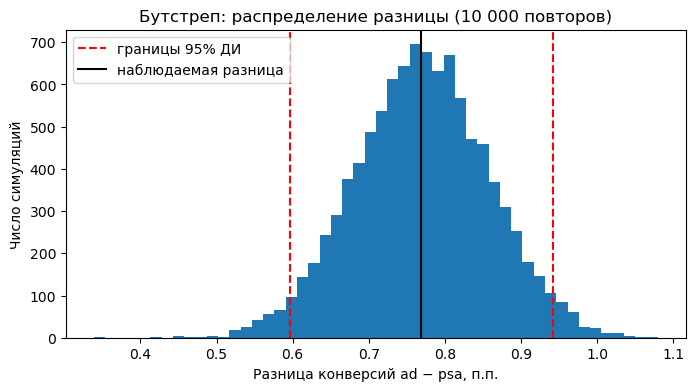

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(boot_diff * 100, bins=50)

plt.axvline(boot_low * 100, color="red", linestyle="--", label="границы 95% ДИ")
plt.axvline(boot_high * 100, color="red", linestyle="--")
plt.axvline(diff * 100, color="black", label="наблюдаемая разница")

plt.xlabel("Разница конверсий ad − psa, п.п.")
plt.ylabel("Число симуляций")
plt.title("Бутстреп: распределение разницы (10 000 повторов)")
plt.legend()
plt.savefig("../images/bootstrap_diff.png", dpi=150, bbox_inches="tight")
plt.show()

## Этап 5. Бутстреп

- 10 000 повторов (ресэмплинг с возвращением), перцентильный 95% ДИ: [0,60; 0,94] п.п.
- Совпадает с интервалом Вальда [0,60; 0,94] — вывод не зависит от метода
- Гистограмма показывает, какую разницу мы могли бы получить, если бы
  повторили эксперимент много раз. Распределение — почти симметричный
  колокол вокруг 0,77 п.п., поэтому формула и симуляция дали одно и то же.
  Ни в одном из 10 000 повторов разница не опустилась до нуля:
  случайность не может объяснить эффект рекламы.

![Бутстреп-распределение разницы](../images/bootstrap_diff.png)

In [14]:
# 1. Сколько купили бы в ad без рекламы (по конверсии контроля)
expected_ad = p_psa * n_ad

# 2. Инкремент и его интервал
incremental = x_ad - expected_ad
inc_low = ci_low * n_ad
inc_high = ci_high * n_ad

# 3. Доля инкремента и цена контроля
share = incremental / x_ad
control_cost = diff * n_psa

print("Купили бы и без рекламы:", round(expected_ad))
print("Инкремент:", round(incremental), "[", round(inc_low), ";", round(inc_high), "]")
print("Доля инкремента в покупках ad, %:", round(share * 100, 1))
print("Цена контроля, покупок:", round(control_cost))

Купили бы и без рекламы: 10080
Инкремент: 4343 [ 3360 ; 5326 ]
Доля инкремента в покупках ad, %: 30.1
Цена контроля, покупок: 181


## Этап 6. Инкрементальность

- Покупок в ad: 14 423, из них купили бы и без рекламы: 10 080
- Инкремент (заслуга рекламы): 4 343 покупки, 95% ДИ [3 360; 5 326] — 30,1% покупок ad
- Цена контроля: 181 недополученная покупка в psa
- Приписать рекламе все 14 423 покупки нельзя: 70% из них случились бы
  и без неё. Без контрольной группы эффект рекламы был бы завышен
  больше чем втрое.
- Контроль стоил своей цены: 181 покупка (около 4% от инкремента) —
  плата за то, чтобы узнать реальный эффект. Перевести покупки в деньги
  нельзя: в данных нет среднего чека и маржи.